<a href="https://colab.research.google.com/github/Shritant/Inspirit_AIColabs/blob/main/Stellar_Classification_Dataset_(SDSS17).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
fedesoriano_stellar_classification_dataset_sdss17_path = kagglehub.dataset_download('fedesoriano/stellar-classification-dataset-sdss17')

print('Data source import complete.')


Using Colab cache for faster access to the 'stellar-classification-dataset-sdss17' dataset.
Data source import complete.


In [ ]:
fedesoriano_stellar_classification_dataset_sdss17_path

'/kaggle/input/stellar-classification-dataset-sdss17'

# 🌟 Introduction

Dataset used in this notebook aims to classificate stars, galaxies, and quasars based on their spectral characteristics. Support Vector Machine (SVM) and Random Forest algorithms are used for classification purposes in this notebook. The dataset is an imbalanced dataset. For this reason, Synthetic Minority Oversampling Technique (SMOTE) is used to eliminate the imbalance between classes. Outlier values are detected with the Local Outlier Factor and these values are removed from the dataset. In the 16-dimensional data set, the correlations of the features with the class label are checked and the features with a correlation greater than 0.16 are used for classification. In addition, the seaborn library and the yellow brick library are used for data visualization.

<img src="https://media2.giphy.com/media/OYfQ5c7FPeBxe/giphy.gif">

### 💫 Content

1. [Load and Check Data](#1)
1. [Detect Outliers](#2)
1. [Feature Selection](#3)
1. [Dealing with Imbalanced Data](#4)
1. [Data Scaling](#5)
1. [Import Libraries](#6)
1. [Train / Test Split](#7)
1. [Classifiers](#8)
    * [SVM Classifier](#9)
        * [Confusion Matrix](#10)
        * [Classification Report](#11)
        * [ROC Curve](#12)
        * [Class Prediction Error](#13)
    * [Random Forest Classifier](#14)
        * [Confusion Matrix](#15)
        * [Classification Report](#16)
        * [ROC Curve](#17)
        * [Class Prediction Error](#18)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk(fedesoriano_stellar_classification_dataset_sdss17_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/stellar-classification-dataset-sdss17/star_classification.csv


<a id='1'></a><br>
# Load and Check Data

In [ ]:
df= pd.read_csv(fedesoriano_stellar_classification_dataset_sdss17_path+"/star_classification.csv")

In [ ]:
df

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [ ]:
df["class"].value_counts()

,count
class,
GALAXY,59445
STAR,21594
QSO,18961


In [ ]:
# Majority Class Baseline
59445/(59445+21594+18961)

0.59445

In [ ]:
df["class"]=[1 if i == "GALAXY" else 0 if i == "STAR" else 2 for i in df["class"]]

<a id='2'></a><br>
# Detect Outliers

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
clf = LocalOutlierFactor()
y_pred = clf.fit_predict(df)

In [ ]:
x_score = clf.negative_outlier_factor_
outlier_score = pd.DataFrame()
outlier_score["score"] = x_score

#threshold
threshold2 = -1.5
filtre2 = outlier_score["score"] < threshold2
outlier_index = outlier_score[filtre2].index.tolist()

In [ ]:
len(outlier_index)

15256

In [ ]:
df.drop(outlier_index, inplace=True)

<a id='3'></a><br>
# Feature Selection

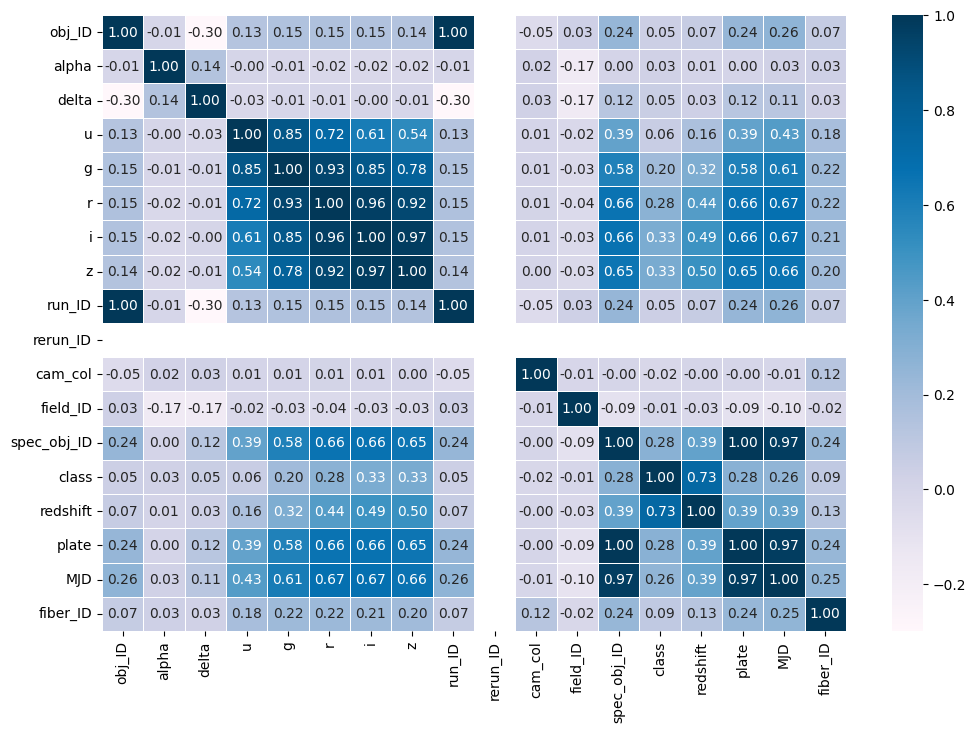

In [ ]:
import seaborn as sns
f,ax = plt.subplots(figsize=(12,8))
sns.heatmap(df.corr(), cmap="PuBu", annot=True, linewidths=0.5, fmt= '.2f',ax=ax)
plt.show()

In [ ]:
corr = df.corr()

In [ ]:
corr["class"].sort_values()

,class
cam_col,-0.016598
field_ID,-0.005333
alpha,0.027144
obj_ID,0.046111
run_ID,0.046112
delta,0.053106
u,0.059976
fiber_ID,0.087157
g,0.204398
MJD,0.257903


In [ ]:
df = df.drop(['obj_ID','alpha','delta','run_ID','rerun_ID','cam_col','field_ID','fiber_ID'], axis = 1)

<a id='4'></a><br>
# Dealing with Imbalanced Data

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
x = df.drop(['class'], axis = 1)
y = df.loc[:,'class'].values

In [ ]:
sm = SMOTE(random_state=42)
print('Original dataset shape %s' % Counter(y))
x, y = sm.fit_resample(x, y)
print('Resampled dataset shape %s' % Counter(y))

Original dataset shape Counter({np.int64(1): 50695, np.int64(0): 17890, np.int64(2): 16159})
Resampled dataset shape Counter({np.int64(1): 50695, np.int64(2): 50695, np.int64(0): 50695})


<a id='5'></a><br>
# Data Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)
x = scaler.transform(x)

<a id='6'></a><br>
# Import Libraries

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report


from yellowbrick.classifier import ConfusionMatrix
from yellowbrick.classifier import ClassPredictionError
from yellowbrick.classifier import ROCAUC
from yellowbrick.style import set_palette

<a id='7'></a><br>
# Train / Test Split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33, random_state = 42, stratify=y)

In [ ]:
np.unique(y_test, return_counts=True)

(array([0, 1, 2]), array([16729, 16730, 16730]))

In [ ]:
16730/(16729+2*16730)

0.3333399748948973

<a id='8'></a><br>
# Classifiers

<a id='9'></a><br>
## SVM Classifier

In [ ]:
svm_clf = svm.SVC(kernel='rbf', C=1, random_state=0)
svm_clf.fit(x_train,y_train)
predicted = svm_clf.predict(x_test)
score = svm_clf.score(x_test, y_test)
svm_score_ = np.mean(score)

print('Accuracy : %.3f' % (svm_score_))

Accuracy : 0.971


In [ ]:
classes = ['GALAXY','STAR','QSO']

<a id='10'></a><br>
### Confusion Matrix

In [ ]:
svm_cm = ConfusionMatrix(svm_clf, classes=classes, cmap='GnBu')

svm_cm.fit(x_train, y_train)
svm_cm.score(x_test, y_test)
svm_cm.show()

<a id='11'></a><br>
### Classification Report

In [ ]:
print(classification_report(y_test, predicted))

<a id='12'></a><br>
### ROC Curve

In [ ]:
visualizer = ROCAUC(svm_clf, classes=classes)

set_palette('bold')

visualizer.fit(x_train, y_train)        # Fit the training data to the visualizer
visualizer.score(x_test, y_test)        # Evaluate the model on the test data
visualizer.show()                       # Finalize and render the figure

<a id='13'></a><br>
### Class Prediction Error

In [ ]:
visualizer = ClassPredictionError(svm_clf, classes=classes)

set_palette('pastel')

visualizer.fit(x_train, y_train)        # Fit the training data to the visualizer
visualizer.score(x_test, y_test)        # Evaluate the model on the test data
visualizer.show()                       # Draw visualization

<a id='14'></a><br>
## Random Forest Classifier

In [ ]:
r_forest = RandomForestClassifier()
r_forest.fit(x_train,y_train)
predicted = r_forest.predict(x_test)
score = r_forest.score(x_test, y_test)
rf_score_ = np.mean(score)

print('Accuracy : %.3f' % (rf_score_))

<a id='15'></a><br>
### Confusion Matrix

In [ ]:
r_forest_cm = ConfusionMatrix(r_forest, classes=classes, cmap='GnBu')

r_forest_cm.fit(x_train, y_train)
r_forest_cm.score(x_test, y_test)
r_forest_cm.show()

<a id='16'></a><br>
### Classification Report

In [ ]:
print(classification_report(y_test, predicted))

<a id='17'></a><br>
### ROC Curve

In [ ]:
visualizer = ROCAUC(r_forest, classes=["GALAXY", "STAR", "QSO"])

set_palette('bold')

visualizer.fit(x_train, y_train)
visualizer.score(x_test, y_test)
visualizer.show()

<a id='18'></a><br>
### Class Prediction Error

In [ ]:
visualizer = ClassPredictionError(r_forest, classes=classes)

set_palette('pastel')

visualizer.fit(x_train, y_train)
visualizer.score(x_test, y_test)
visualizer.show()